In [1]:
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
from tdse_solutions import *

In [2]:
def get_inf_arr_from_phase_residuals(phase_res_arr, n_ions):
    n_ions_max = phase_res_arr.shape[2] - 1
    inf_arr = np.zeros((phase_res_arr.shape[0], phase_res_arr.shape[1]))
    
    for i in range(phase_res_arr.shape[0]):
        for j in range(phase_res_arr.shape[1]):
            delta_n = int((n_ions_max - n_ions)/2)
            phase_res = phase_res_arr[i, j]
            if delta_n == 0:
                phase_res_part = phase_res
            else:
                phase_res_part = phase_res[delta_n:-delta_n]
            inf_arr[i, j] = 1 - fidelity_from_phase_residuals(phase_res_part)
    return inf_arr

In [3]:
def get_line_of_minima(x, y, values):
    nx, ny = values.shape

    min_x = []
    min_y = []

    def lin_func(x, a, b):
        return a + b*x
    
    for i in range(nx):
        min_j = np.argmin(values[i])
        if min_j in [0, ny-1]:
            continue
        min_x.append(x[i])
        min_y.append(y[min_j])

    return curve_fit(lin_func, min_x, min_y)[0]

In [4]:
datafile = np.load('../data/phase_res_2d_dep_lemniscate_sym_20_ions_full_ham_eta_0-03.npz')

delta_a_range = datafile['delta_a_range']
rel_f_range = datafile['rel_f_range']
phase_res_arr = datafile['phase_res_arr']

In [5]:
n_ions = 20
inf_arr = get_inf_arr_from_phase_residuals(phase_res_arr, n_ions)
rel_f_shift, delta_a_coef = get_line_of_minima(delta_a_range, rel_f_range-1, inf_arr)
#rel_f_shift, delta_a_coef
inf_arr_interp = RegularGridInterpolator([delta_a_range, rel_f_range-1], inf_arr, bounds_error=False, method='cubic')

# Single panel version

In [6]:
%matplotlib inline

plt.close('all')

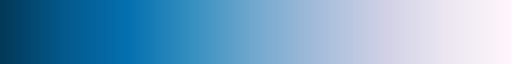

In [7]:
cmap = plt.get_cmap('PuBu')
cmap.reversed()

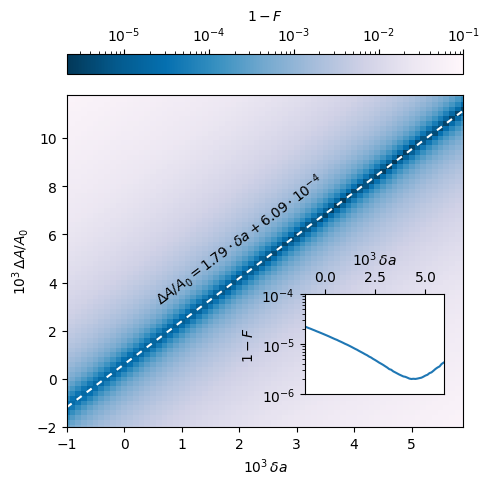

In [11]:
fig, ax1 = plt.subplots(1, 1, figsize=(5,5))
ax2 = ax1.inset_axes([0.6, 0.1, 0.35, 0.3])

res1 = ax1.pcolormesh(delta_a_range*1e3, (rel_f_range-1)*1e3, inf_arr.T, 
              norm=matplotlib.colors.LogNorm(inf_arr.min(), 1e-1),
              cmap=plt.get_cmap('PuBu').reversed(), rasterized=True)
ax1.set_xlabel('$10^{3}\, \delta a$')
ax1.set_ylabel(r'$10^{3}\,\Delta A/ A_0$')
ax1.plot(delta_a_range*1e3, (rel_f_shift + delta_a_coef*delta_a_range)*1e3, 
         color='white', linestyle=(0, (3,3)))
ax1.set_xlim(delta_a_range[0]*1e3, delta_a_range[-1]*1e3)
ax1.set_ylim((rel_f_range[0]-1)*1e3, (rel_f_range[-1]-1)*1e3)

line_eq_text = rf'$\Delta A/A_0 = {delta_a_coef:.2f}\cdot\delta a + {rel_f_shift*1e4:.2f}\cdot 10^{{-4}}$'

cbar = plt.colorbar(res1, ax=ax1, location='top')
cbar.set_label('$1-F$')

#ax1.text(0.03, 0.97, '(a)', verticalalignment='top', transform=ax1.transAxes, color='w', fontsize=20)

#ax2.set_title(line_eq_text)
ax2.plot(delta_a_range*1e3, [inf_arr_interp([delta_a, rel_f_shift + delta_a_coef*delta_a]) for delta_a in delta_a_range])
ax2.set_xlabel(r'$10^{3} \,\delta a $')
ax2.set_yscale('log')
ax2.set_ylabel('$1-F$')
ax2.set_ylim(1e-6, 1e-4)
#ax2.yaxis.set_ticks_position('right')
#ax2.yaxis.set_label_position('right')
ax2.margins(x=0)
ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')
#ax2.text(0.03, 0.97, '(b)', verticalalignment='top', transform=ax2.transAxes, fontsize=20)

plt.tight_layout()
angle = ax1.transData.transform_angles([np.atan(delta_a_coef)/np.pi*180], [(10,0.002)])[0]
ax1.text(2, 5.8, line_eq_text, rotation=angle, color='k', 
         rotation_mode='anchor', 
         horizontalalignment='center',
         verticalalignment='center')

#
#plt.savefig('../figures/lemniscate_fidelity_2d_dep.pdf', dpi=300)
plt.show()

# Two panel version

In [16]:
plt.close('all')

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.4,10), 
                               gridspec_kw={'height_ratios' : [1., 0.5]}
                              )

res1 = ax1.pcolormesh(delta_a_range*1e3, (rel_f_range-1), inf_arr.T, norm=matplotlib.colors.LogNorm(inf_arr.min(), inf_arr.max()),
              cmap=plt.get_cmap('PuBu'), rasterized=True)
ax1.set_xlabel('$\delta a \cdot 10^{3}$')
ax1.set_ylabel(r'$\Delta A/ A_0$')
ax1.plot(delta_a_range*1e3, rel_f_shift + delta_a_coef*delta_a_range, 'k--')
ax1.set_xlim(delta_a_range[0]*1e3, delta_a_range[-1]*1e3)
ax1.set_ylim(rel_f_range[0]-1, rel_f_range[-1]-1)

line_eq_text = rf'$\Delta A/A_0 = {delta_a_coef:.2f}\cdot\delta a + {rel_f_shift*1e4:.2f}\cdot 10^{{-4}}$'

cbar = plt.colorbar(res1, ax=ax1, location='top')
cbar.set_label('$1-F$')

ax1.text(0.03, 0.97, '(a)', verticalalignment='top', transform=ax1.transAxes, color='w', fontsize=20)

#ax2.set_title(line_eq_text)
ax2.plot(delta_a_range*1e3, [inf_arr_interp([delta_a, rel_f_shift + delta_a_coef*delta_a]) for delta_a in delta_a_range])
ax2.set_xlabel(r'$\delta a\cdot 10^{3}$')
ax2.set_yscale('log')
ax2.set_ylabel('$1-F$')
ax2.set_ylim(1e-6, 1e-4)
#ax2.yaxis.set_ticks_position('right')
#ax2.yaxis.set_label_position('right')
ax2.margins(x=0)
ax2.text(0.03, 0.97, '(b)', verticalalignment='top', transform=ax2.transAxes, fontsize=20)

plt.tight_layout()
angle = ax1.transData.transform_angles([np.atan(delta_a_coef*1e-3)/np.pi*180], [(10,0.002)])[0]
ax1.text(2, 0.005, line_eq_text, rotation=angle, color='k', 
         rotation_mode='anchor', 
         horizontalalignment='center',
         verticalalignment='center')
plt.show()
#
#plt.savefig('../figures/lemniscate_fidelity_2d_dep.pdf', dpi=300)

In [8]:
help(matplotlib.rc)

Help on function rc in module matplotlib:

rc(group, **kwargs)
    Set the current `.rcParams`.  *group* is the grouping for the rc, e.g.,
    for ``lines.linewidth`` the group is ``lines``, for
    ``axes.facecolor``, the group is ``axes``, and so on.  Group may
    also be a list or tuple of group names, e.g., (*xtick*, *ytick*).
    *kwargs* is a dictionary attribute name/value pairs, e.g.,::

      rc('lines', linewidth=2, color='r')

    sets the current `.rcParams` and is equivalent to::

      rcParams['lines.linewidth'] = 2
      rcParams['lines.color'] = 'r'

    The following aliases are available to save typing for interactive users:

    =====   =================
    Alias   Property
    =====   =================
    'lw'    'linewidth'
    'ls'    'linestyle'
    'c'     'color'
    'fc'    'facecolor'
    'ec'    'edgecolor'
    'mew'   'markeredgewidth'
    'aa'    'antialiased'
    =====   =================

    Thus you could abbreviate the above call as::

          r